<a href="https://colab.research.google.com/github/NKontemeniotou/ML-Based-Airline-Satisfaction-Prediction/blob/main/shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()
import pandas as pd
df=pd.read_excel("final3.xlsx")

Saving final3.xlsx to final3 (4).xlsx


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

target= 'satisfaction'
numeric_features = ['Flight Distance', 'Arrival Delay in Minutes','Age','Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking','Gate location','Food and drink','Online boarding', 'Seat comfort','Inflight entertainment','On-board service','Leg room service','Baggage handling','Checkin service','Inflight service','Cleanliness']
binary_features = ['Gender', 'Customer Type', 'Type of Travel']
categorical_nominal = ['Class']

df = pd.read_excel("final3.xlsx")
x=df.drop(columns=['satisfaction','Departure Delay in Minutes'])
y=df[target]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('bin', 'passthrough', binary_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), categorical_nominal)
    ]
)
X_transformed = preprocessor.fit_transform(x)
ohe = preprocessor.named_transformers_['nom']
ohe_feature_names = ohe.get_feature_names_out(categorical_nominal)
feature_names = numeric_features + binary_features + list(ohe_feature_names)
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)
cols_to_drop = ['Class_2', 'Gender', 'Arrival Delay in Minutes', 'Food and drink','Gate location']
X_transformed_df.drop(columns=cols_to_drop, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

best_model=RandomForestClassifier(bootstrap=False,criterion='entropy',max_depth=100,max_features='sqrt',min_samples_leaf=1,min_samples_split=100,n_estimators=500)
X_train, X_test, y_train, y_test = train_test_split(X_transformed_df, y, test_size=0.3, random_state=1)
best_model.fit(X_train, y_train)
best_model_preds = best_model.predict(X_test)


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
explainer = shap.TreeExplainer(best_model)
explanation = explainer(X_test)

NameError: name 'shap' is not defined

In [ ]:
print(X_test.shape, best_model.n_features_in_)

(9000, 18) 18


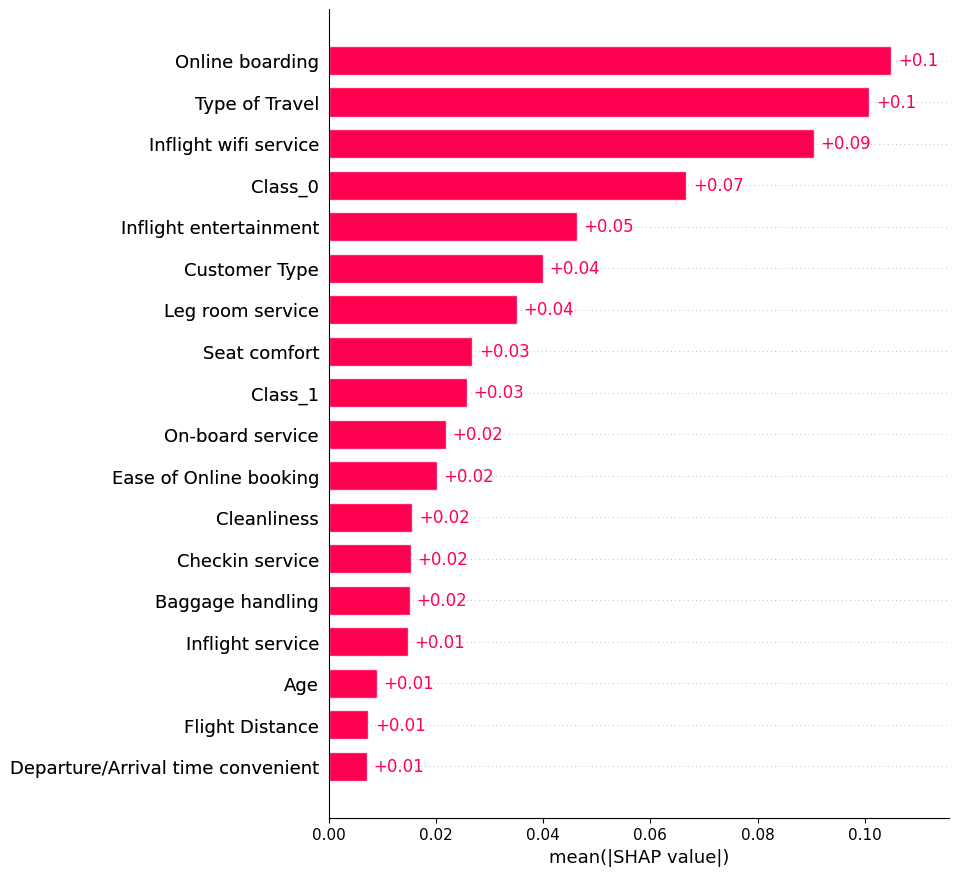

In [ ]:
explanation_class0 = shap.Explanation(
    values=explanation.values[:, :, 0],
    base_values=explanation.base_values[:, 0],
    data=X_test,
    feature_names=X_test.columns
)
shap.plots.bar(explanation_class0, max_display=18)

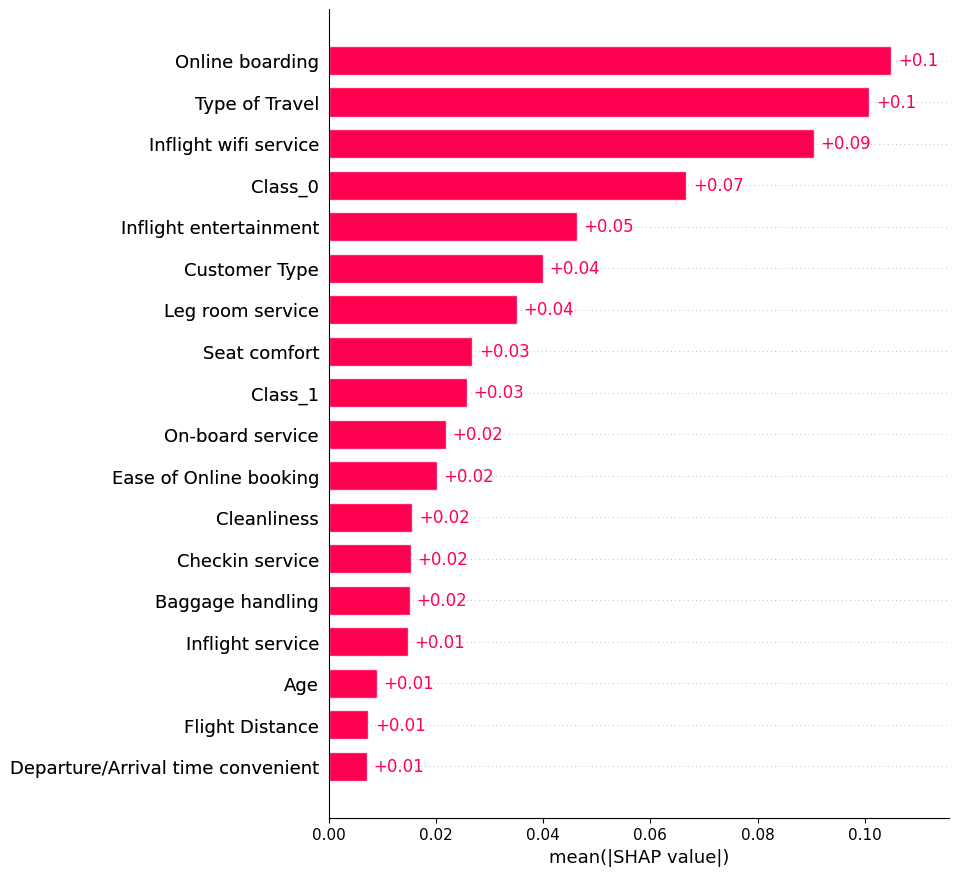

In [ ]:
explanation_class1 = shap.Explanation(
    values=explanation.values[:, :, 1],
    base_values=explanation.base_values[:, 1],
    data=X_test,
    feature_names=X_test.columns
)
shap.plots.bar(explanation_class1, max_display=18)

In [ ]:
print(df.columns)  # see if integer 16 is a column name



Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


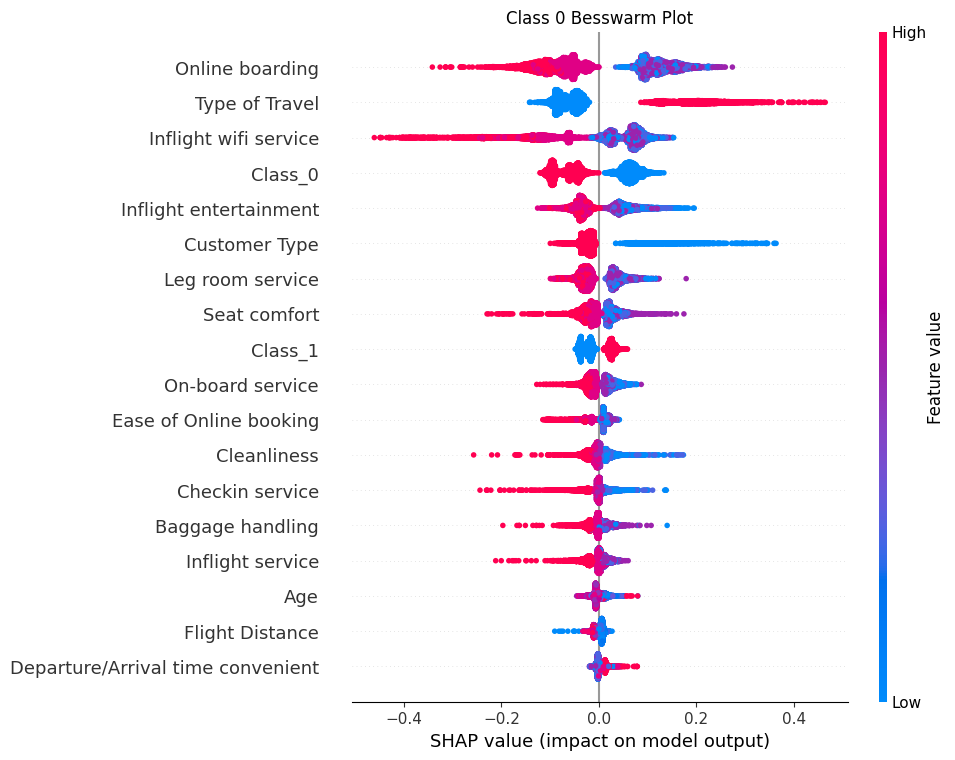

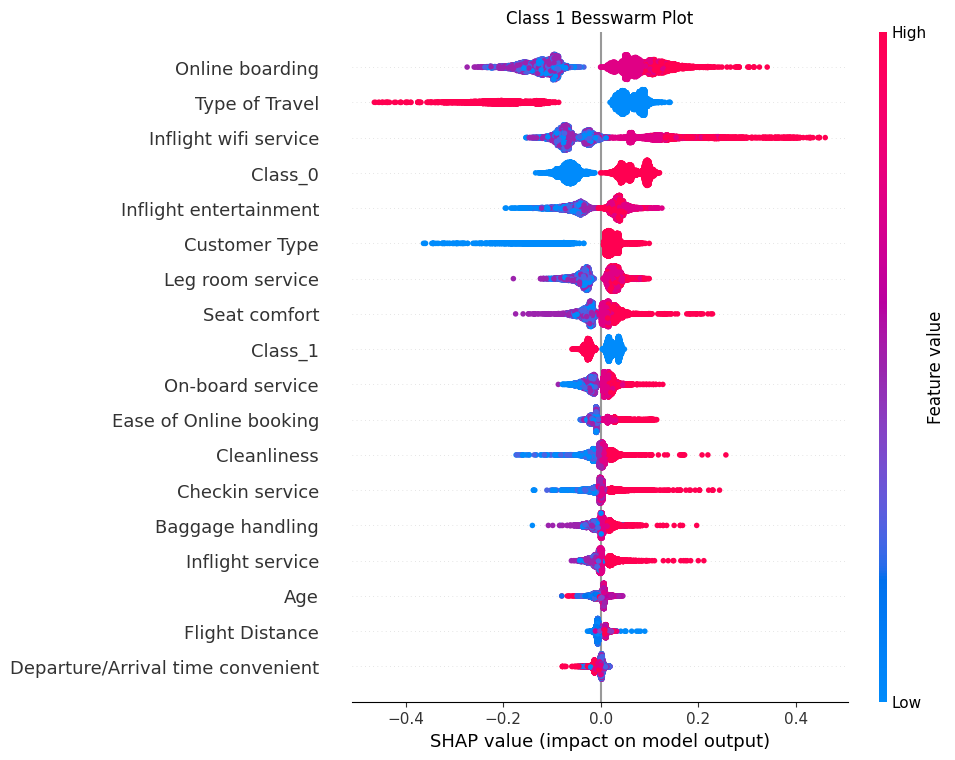

In [ ]:
#beeswarm
import matplotlib.pyplot as plt

#class0
plt.figure(figsize=(10,6))
shap.plots.beeswarm(explanation_class0, max_display=18, show=False)
plt.title("Class 0 Besswarm Plot")
plt.show()

#class1
plt.figure(figsize=(10,6))
shap.plots.beeswarm(explanation_class1, max_display=18, show=False)
plt.title("Class 1 Besswarm Plot")
plt.show()

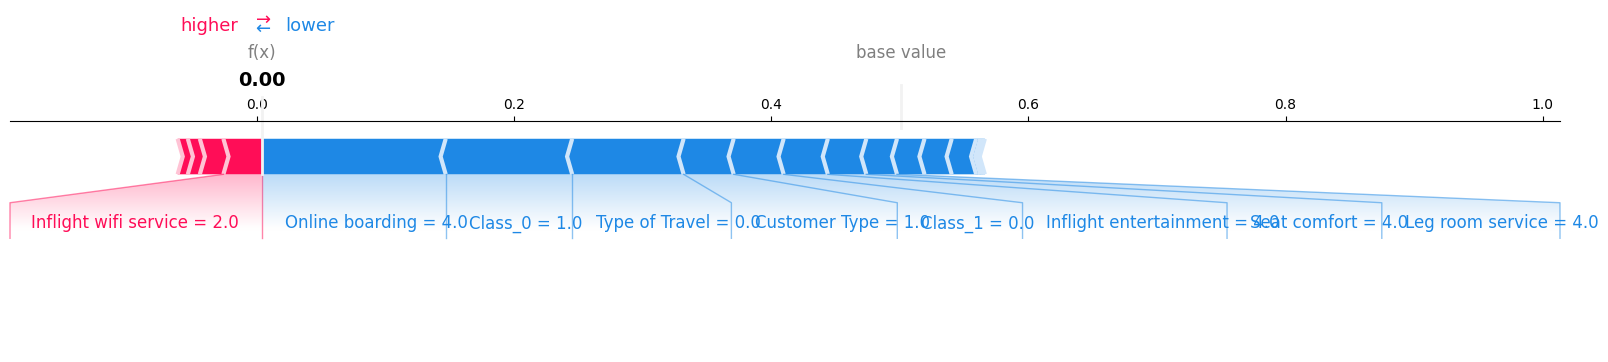

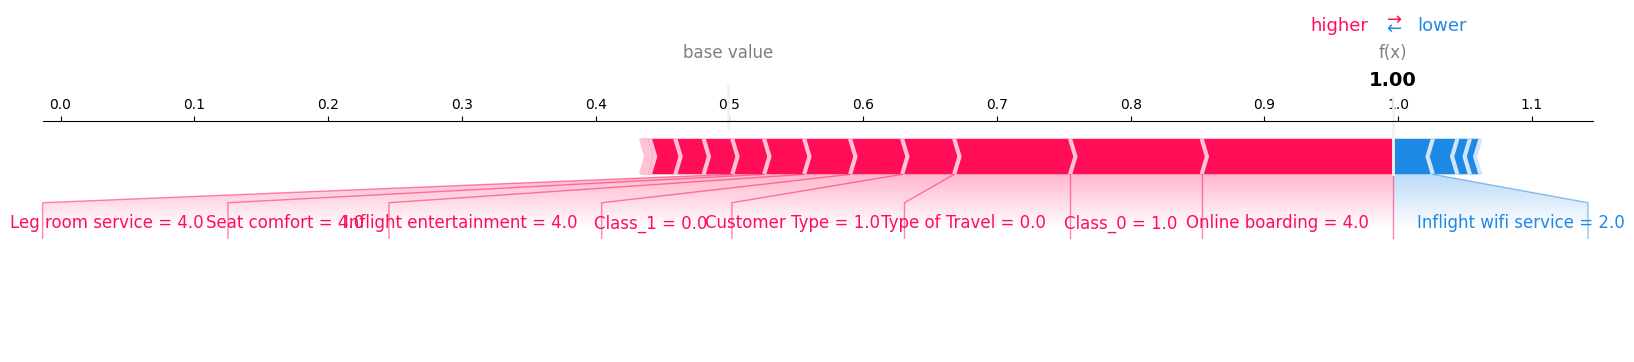

In [ ]:
# Πρώτη τυχαία παρατήρηση
i = np.random.randint(0, len(X_test))
X_one = X_test.iloc[[i]]

# Class 0
shap_values_class0 = explanation.values[[i],:,0]
explanation_class0_one = shap.Explanation(
    values=shap_values_class0,
    base_values=explanation.base_values[[i],0],
    data=X_one,
    feature_names=X_test.columns
)
shap.plots.force(explanation_class0_one, matplotlib=True, show=True)

# Class 1
shap_values_class1 = explanation.values[[i],:,1]
explanation_class1_one = shap.Explanation(
    values=shap_values_class1,
    base_values=explanation.base_values[[i],1],
    data=X_one,
    feature_names=X_test.columns
)
shap.plots.force(explanation_class1_one, matplotlib=True, show=True)



In [ ]:
# Πρώτη τυχαία παρατήρηση
i = np.random.randint(0, len(X_test))
X_one = X_test.iloc[[i]]

# Class 0
shap_values_class0 = explanation.values[[i],:,0]
explanation_class0_one = shap.Explanation(
    values=shap_values_class0,
    base_values=explanation.base_values[[i],0],
    data=X_one,
    feature_names=X_test.columns
)
shap.plots.force(
    explanation_class0_one,
    matplotlib=True,
    show=True,
    max_display=10)
#Class 1
shap_values_class1 = explanation.values[[i],:,1]
explanation_class1_one = shap.Explanation(
    values=shap_values_class1,
    base_values=explanation.base_values[[i],1],
    data=X_one,
    feature_names=X_test.columns
)
shap.plots.force(
    explanation_class1_one,
    matplotlib=True,
    show=True,
    max_display=10)

TypeError: force() got an unexpected keyword argument 'max_display'

In [ ]:
!pip install --upgrade shap

In [ ]:
import shap
shap.initjs()  # Φορτώνει την JS βιβλιοθήκη για τα interactive plots

# Τυχαίες 10 παρατηρήσεις
import numpy as np
idx = np.random.choice(range(len(X_test)), 10, replace=False)
X_sample = X_test.iloc[idx]

# --- Class 0 ---
shap_values_class0 = explanation.values[idx,:,0]
explanation_class0_sample = shap.Explanation(
    values=shap_values_class0,
    base_values=explanation.base_values[idx,0],
    data=X_sample,
    feature_names=X_test.columns
)
print("Class 0")
shap.plots.force(explanation_class0_sample)

# --- Class 1 ---
shap_values_class1 = explanation.values[idx,:,1]
explanation_class1_sample = shap.Explanation(
    values=shap_values_class1,
    base_values=explanation.base_values[idx,1],
    data=X_sample,
    feature_names=X_test.columns
)
print("Class 1")
shap.plots.force(explanation_class1_sample)


Class 0
Class 1
